# Thesaurus word selection

**Recipe 12** · Level 2 (Easy) · Decision type: `Choice`

Choose a context-appropriate synonym from a supplied thesaurus list while retaining the original word when no alternative preserves its meaning.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

A thesaurus-style word selector for four target words (`happy`, `big`, `quick`, `angry`). For each sentence, Python supplies its own small set of candidate synonyms -- built fresh per sentence, not shared by every sentence that happens to use the same word, and offered in a shuffled order so the candidate that fits is not always listed first -- plus a fixed fallback, `keep_original`, for a sentence where none of the candidates preserve the word's meaning. Jev reads one sentence and picks exactly one option. Python then accepts that choice only when it is one Jev was actually offered and its `confidence` clears a threshold chosen on `validation` and frozen afterward; anything else goes to an explicit `review` outcome. Forty sentences carry a [gold label](../../docs/glossary.md#gold-label) (a list of every option that preserves the meaning, since more than one synonym can fit) across `validation` and `test`; three more are shown in this notebook but never scored. By the end you will have looked at individual typed answers -- a clear pick, a correct `keep_original`, and a wrong, confident one -- then the rule, then an evaluation that reports the share of selections inside each sentence's acceptable set, how correctly the rule uses `keep_original`, and the coverage, accuracy and risk the frozen threshold buys.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 43 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    evaluate_outcomes,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
    selective_curve,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_risk_coverage,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 43 examples in fixtures/ has its own candidate list, so its own question;
# this cache makes sure a sentence that is shown individually and later scored in its split is
# decided once, so the whole notebook makes exactly 43 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        questions = helpers.build_questions(example.fields["word"], example.fields["candidates"])
        state = helpers.build_state(example.fields)
        answered[example.id] = backend.decide(state, questions)["synonym"]
    return answered[example.id]


run_header(
    12,
    "Thesaurus word selection",
    backend=backend,
    n_examples=len(scored),
)

Recipe 12: Thesaurus word selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 40 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: an `item_id`, the target `word`, the `sentence` it appears in, and this sentence's own `candidates` list. `build_state` passes on the word and the sentence only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model, and the candidate list shapes the question below rather than the state.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-happy-clear"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "item_id": "d01-happy-clear",
  "word": "happy",
  "sentence": "She felt happy and kept smiling through the whole afternoon after hearing the good news.",
  "candidates": [
    "glad",
    "joyful",
    "cheerful"
  ]
}
Jev sees:
{
  "word": "happy",
  "sentence": "She felt happy and kept smiling through the whole afternoon after hearing the good news."
}


## The questions

There is one question, and it asks one thing: which of the supplied words, if any, could replace the target word here without changing the sentence's meaning? A `Choice` fits because the candidates are a short, fixed list and Jev commits to exactly one of them. The option list is not the same for every sentence: Python builds it per sentence from that sentence's own `candidates` (`build_fixtures.py`), not from a table shared by every sentence that happens to use the same word -- two sentences about `big` can be asked to choose from different sets of synonyms. Every option list also carries the shared fallback `keep_original`, for a sentence where none of the candidates preserve the word's meaning -- an idiom, a fixed name, or similar, rather than a sentence the model merely finds hard.

TypeSafe's notes on Jev 1.13 (S07, item 8) document that a `Choice` answer can lean toward whichever option comes first in the list it is given, and recommend reordering the options and checking that the answer stays consistent. `build_fixtures.py` takes this literally: `shuffled_candidates(item_id, candidates)` calls `jev_cookbook.fixtures.stable_shuffle`, keyed on this recipe's slug together with each sentence's own id, to permute its three candidates before they are ever asked about, independently of every other sentence ([fixtures.md](../../docs/fixtures.md#per-item-option-order), "Per-item option order"). Nothing about *which* candidate is correct is decided by this shuffle; that is fixed by the gold label. Only the position a candidate happens to be offered in changes, and the table below shows that it actually does.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` (S03, <https://docs.typesafe.ai/confidence>): 0 when the top option has no more than an even share of the options, 1 when one option holds all the probability. Here `n` is 4 for every sentence in this recipe's fixtures (three candidates plus `keep_original`), so confidence depends only on how far the top probability clears one quarter, not on how the rest is split among the other three options.

In [3]:
example = demo["d01-happy-clear"]
questions = helpers.build_questions(example.fields["word"], example.fields["candidates"])
synonym = questions["synonym"]
print(synonym.instructions)
for name, description in synonym.criteria.items():
    print(f"  {name:12s} {description}")

The word 'happy' appears in the sentence below. Choose the option that could replace 'happy' without changing the sentence's meaning. If none of the supplied words preserve the meaning, choose 'keep_original'.
  glad         pleased about a particular event or piece of news.
  joyful       full of happiness; feeling great pleasure.
  cheerful     noticeably happy and good-humoured.
  keep_original None of the words above preserve the sentence's meaning in place of 'happy' here; keep the original word unchanged.


Shuffling only matters if it actually spreads the gold answer across positions; otherwise it would be a gesture, not a fix. The table below counts, over all 40 scored sentences, which position (1, 2 or 3 among that sentence's own shuffled candidates, or 4 for `keep_original`) its gold set occupies -- several at once where more than one candidate fits. Position 1 is not acceptable in every sentence: `(2,)` and `(3,)` each appear on their own, meaning at least one sentence's *only* acceptable candidate is offered second or third, so "always answer option 1" could not reproduce this rule's accuracy by riding the option order alone.

In [4]:
from collections import Counter

position_counts = Counter()
for e in scored:
    options = [*e.fields["candidates"], "keep_original"]
    positions = tuple(sorted(options.index(name) + 1 for name in labels[e.id]))
    position_counts[positions] += 1

print("gold positions   rows")
for positions, count in sorted(position_counts.items()):
    print(f"  {str(positions):14s} {count}")

gold positions   rows
  (1,)           2
  (1, 2)         10
  (1, 2, 3)      1
  (1, 3)         8
  (2,)           2
  (2, 3)         8
  (3,)           1
  (4,)           8


## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a sentence with a clear, confident replacement; a sentence where none of the candidates fit and the stored answer correctly keeps the original word; and a sentence where the stored answer is wrong and confident. All three are `demo` examples, never scored, so nothing shown here reaches into a split the evaluation below reports on. Each answer holds the chosen option, a probability for every option (this sentence's own candidates plus `keep_original`), the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

She felt happy and kept smiling through the whole afternoon after hearing the good news.
Choice: joyful (confidence 0.87)
  joyful         0.90  ##################
  cheerful       0.06  #
  glad           0.03  #
  keep_original  0.01  
Provenance: synthetic


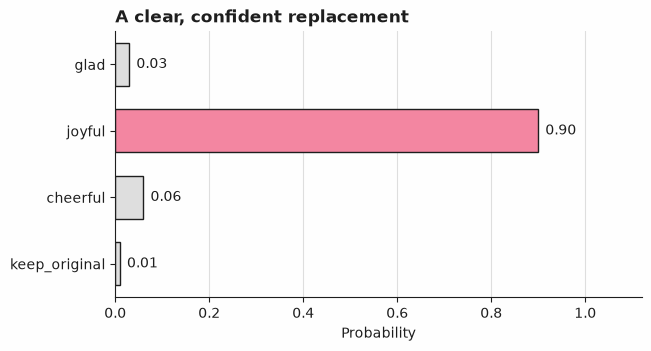

In [5]:
clear_example = demo["d01-happy-clear"]
clear_answer = decide(clear_example)
print(clear_example.fields["sentence"])
show_answer(clear_answer)
plot_answer_probabilities(clear_answer, title="A clear, confident replacement")

"She felt happy and kept smiling through the whole afternoon after hearing the good news." names a straightforward positive reaction, with nothing to complicate it. The stored answer puts `joyful` on top at 0.90, so `confidence` is 0.87: `(0.90 - 0.25) / 0.75`. The other two candidates, `cheerful` and `glad`, and the fallback `keep_original`, share what is left.

It's a big ask, but I think the team can pull it off before the deadline.
Choice: keep_original (confidence 0.77)
  keep_original  0.83  #################
  large          0.08  ##
  sizable        0.06  #
  massive        0.03  #
Provenance: synthetic


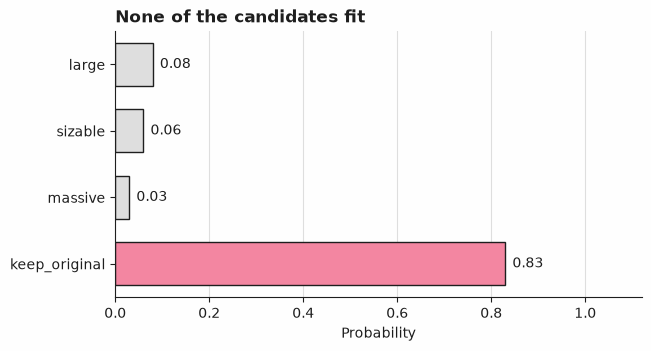

In [6]:
nomatch_example = demo["d02-big-nomatch"]
nomatch_answer = decide(nomatch_example)
print(nomatch_example.fields["sentence"])
show_answer(nomatch_answer)
plot_answer_probabilities(nomatch_answer, title="None of the candidates fit")

"It's a big ask, but I think the team can pull it off before the deadline." uses `big` to mean a lot to ask for, not physically large: none of `large`, `sizable` or `massive` preserve that meaning, so the only acceptable reading is to leave the word alone. The stored answer agrees, putting `keep_original` on top at 0.83 (confidence 0.77). This is exactly the hard case the use case names, and exactly why `keep_original` is a real, final answer rather than an automatic review flag (`helpers.resolve`, below): a confident, correct `keep_original` like this one should be reported, not routed to a person for no reason -- and, as the evaluation below shows, a confident `keep_original` is not always correct either.

The negotiations turned angry fast once the topic of layoffs came up, and voices started rising around the table.
Choice: irritated (confidence 0.87)
  irritated      0.90  ##################
  furious        0.05  #
  annoyed        0.03  #
  keep_original  0.02  
Provenance: synthetic


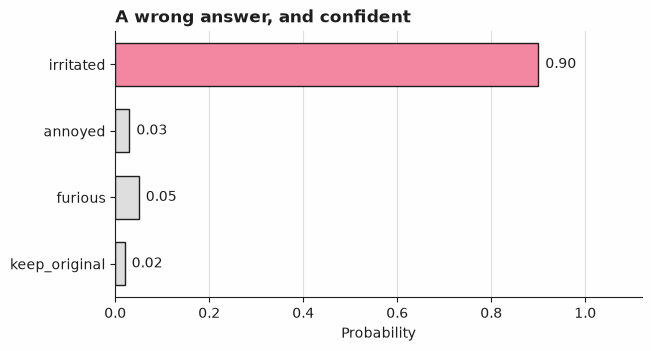

In [7]:
wrong_example = demo["d03-angry-wrong"]
wrong_answer = decide(wrong_example)
print(wrong_example.fields["sentence"])
show_answer(wrong_answer)
plot_answer_probabilities(wrong_answer, title="A wrong answer, and confident")

"The negotiations turned angry fast once the topic of layoffs came up, and voices started rising around the table." describes anger that is escalating and loud, not the mild, persistent-or-minor irritation the `irritated` gloss names. The stored answer calls it `irritated` anyway, at confidence 0.87. This is a `demo` example, so nothing here is scored; it exists to show, before any aggregate number, that a wrong answer can still be a confident one -- the same shape `t05-quick-wrong` and `t05-big-fp` have in `test`, discussed again below once the evaluation has reported on them. Nothing here says *why* a real model would get a sentence like this wrong, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the choice; what happens with it is code. `resolve` in `helpers.py` accepts the chosen option as given only when it is one of the sentence's own candidates or `keep_original` *and* the answer's `confidence` is at or above a threshold. One thing sends it to review regardless of confidence: choosing something that was never offered -- defensive: the backend already restricts an answer to the question's own options (`docs/backends.md`), so this branch cannot fire through replay or live, but the rule does not trust that silently. Unlike recipe 07's `unclear` (a Choice option that only ever means "the model could not decide", and so is sent to review whatever its confidence), `keep_original` here is a real, final answer: it is the correct, scorable outcome whenever a fixture's gold set says no candidate fits, it triggers no side effect of its own, and `resolve` holds it to exactly the same [confidence gate](../../docs/glossary.md#confidence-gate) as every other option rather than an automatic review -- including when it is the *wrong* choice: `v05-happy-fp` and `t05-big-fp` below both carry a stored answer of `keep_original` when a real candidate actually fit, one unconfidently and one confidently, so the fallback's own failure mode is on the page, not only its successes. `tests/test_helpers.py` checks every branch for every kind of option this recipe asks about.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose accepted subset of the 20 `validation` sentences is perfectly accurate -- "accurate" here meaning the chosen option is inside that sentence's own gold set of acceptable choices, not a single exact label, since more than one synonym can fit. Two `validation` sentences are wrong: `v05-angry-wrong` names `livid` ("extremely angry; furiously enraged") for a sentence that says outright "a little angry ... he just shrugged and went back to reading his book" -- the sentence's own words contradict that gloss directly, not a judgment call -- and `v05-happy-fp` answers `keep_original` at a low confidence even though `content` and `glad` both fit. Excluding both from the accepted set is what the search below actually has to do. Applying that frozen threshold to the three answers shown above, plus two more for contrast (a sentence the rule sends to review for low confidence despite naming an acceptable option, and the false `keep_original` just described), shows every outcome the rule can produce.

In [8]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice in g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(
    f"answers whose choice is inside its sentence's acceptable set: {sum(val_correct)} of "
    f"{len(val_correct)}{selection}{check}"
)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

low_example = next(e for e in val_examples if e.id == "v04-happy-low")
low_answer = decide(low_example)
fp_example = next(e for e in val_examples if e.id == "v05-happy-fp")
fp_answer = decide(fp_example)
for shown_example, shown_answer in (
    (clear_example, clear_answer),
    (nomatch_example, nomatch_answer),
    (wrong_example, wrong_answer),
    (low_example, low_answer),
    (fp_example, fp_answer),
):
    candidates = shown_example.fields["candidates"]
    result = helpers.resolve(shown_example.fields["item_id"], shown_answer, candidates, threshold)
    print(
        f"{result.item_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )

answers whose choice is inside its sentence's acceptable set: 18 of 20 (a selection step, not a reported result) (a pipeline check, not a Jev result)
chosen threshold, frozen from here on: 0.7333 (a selection step, not a reported result) (a pipeline check, not a Jev result)
d01-happy-clear: joyful at confidence 0.87 -> accepted (confident)
d02-big-nomatch: keep_original at confidence 0.77 -> accepted (confident)
d03-angry-wrong: irritated at confidence 0.87 -> accepted (confident)
v04-happy-low: content at confidence 0.20 -> review (confidence below the threshold)
v05-happy-fp: keep_original at confidence 0.17 -> review (confidence below the threshold)


One more thing worth seeing before `test` is touched: what the threshold search on `validation` actually had to choose between. `selective_curve` sweeps every distinct confidence value observed on `validation` and reports the accuracy and coverage of answering at or above it; the threshold frozen above is exactly the point on this curve with the lowest confidence (so the most coverage) whose accuracy is still 1.0.

validation confidence sweep (selective_curve):
  threshold 0.8400  coverage 0.0500  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  threshold 0.8267  coverage 0.1000  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  threshold 0.8133  coverage 0.2000  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  threshold 0.8000  coverage 0.3000  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  threshold 0.7600  coverage 0.4000  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  threshold 0.7467  coverage 0.5000  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  threshold 0.7333  coverage 0.7000  accuracy 1.0000  risk 0.0000 (a selection step

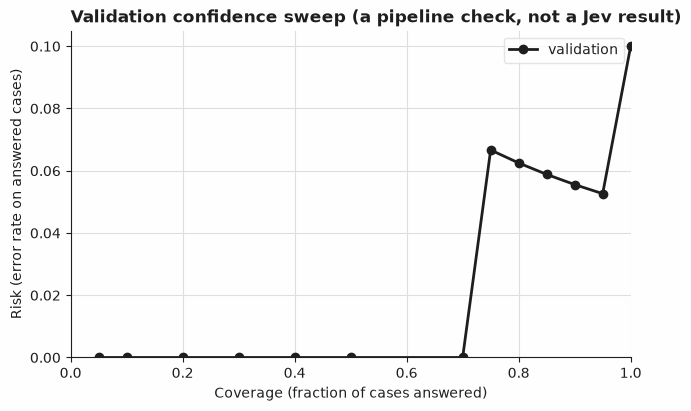

In [9]:
val_curve = selective_curve(val_correct, val_confidence)
print("validation confidence sweep (selective_curve):")
for th, cov, acc, risk in zip(
    val_curve.thresholds, val_curve.coverage, val_curve.accuracy, val_curve.risk, strict=True
):
    print(
        f"  threshold {th:.4f}  coverage {cov:.4f}  accuracy {acc:.4f}  risk {risk:.4f}"
        f"{selection}{check}"
    )
plot_risk_coverage(
    val_curve.coverage,
    val_curve.risk,
    label="validation",
    title=f"Validation confidence sweep{check}",
)

Accuracy stays at 1.0000 from threshold 0.8400 down through 0.7333, and coverage climbs from 0.0500 to 0.7000 across that same stretch -- every sentence in that confidence range is correct, so there is nothing to lose by including it. The jump happens at the next lower observed value, 0.4000: accuracy falls to 0.9333 the moment that threshold (`v05-angry-wrong`'s own confidence) is included, because it is the first wrong answer the sweep reaches. `select_confidence_threshold(..., target_accuracy=1.0)` stops at 0.7333, the lowest confidence before that fall, which is why the frozen threshold lands exactly there rather than at some other point in the 0.7333-to-0.8400 stretch that would have scored identically on `validation`.

## Evaluation

Both ingredients were chosen above: the candidates (and their offered order) by Python, per sentence, and the confidence threshold on `validation`. This section reports what the frozen rule does: `helpers.resolve` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, this section reports two further numbers: the share of selections that land inside each sentence's own acceptable set -- the raw `Choice`, before the confidence gate removes anything -- and how correctly the rule uses `keep_original`: precision and recall of that one option against the sentences whose gold set says it is the only acceptable answer. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [10]:
def report(chosen, decided, gold, threshold):
    """Apply resolve to every answer and tally what it actually did."""
    results = [
        helpers.resolve(e.fields["item_id"], a, e.fields["candidates"], threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    in_set = [a.choice in g for a, g in zip(decided, gold, strict=True)]
    accepted = [
        (a, g)
        for r, a, g in zip(results, decided, gold, strict=True)
        if r.outcome == helpers.ACCEPTED
    ]
    right = sum(a.choice in g for a, g in accepted)
    reasons = {}
    for r in results:
        if r.outcome == helpers.REVIEW:
            reasons[r.reason] = reasons.get(r.reason, 0) + 1
    return results, in_set, len(accepted), right, reasons


val_results, val_in_set, n_accepted, n_right, val_reasons = report(
    val_examples, val_answers, val_gold, threshold
)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(
    f"selections inside the acceptable set: {sum(val_in_set)} of {len(val_in_set)} "
    f"({sum(val_in_set) / len(val_in_set):.4f}){selection}{check}"
)
print(
    f"accepted by the rule at this threshold: {n_accepted} of {len(val_examples)}{selection}{check}"
)
print(f"right among those accepted: {n_right} of {n_accepted}{selection}{check}")

validation, 20 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
selections inside the acceptable set: 18 of 20 (0.9000) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accepted by the rule at this threshold: 14 of 20 (a selection step, not a reported result) (a pipeline check, not a Jev result)
right among those accepted: 14 of 14 (a selection step, not a reported result) (a pipeline check, not a Jev result)


In [11]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, test_in_set, n_accepted_t, n_right_t, test_reasons = report(
    test_examples, test_answers, test_gold, threshold
)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(
    f"selections inside the acceptable set: {sum(test_in_set)} of {len(test_in_set)} "
    f"({sum(test_in_set) / len(test_in_set):.4f}){check}"
)
print(f"accepted by the rule: {n_accepted_t} of {len(test_examples)}{check}")
print(f"right among those accepted: {n_right_t} of {n_accepted_t}{check}")
print(f"sent to review: {sum(test_reasons.values())} of {len(test_examples)}{check}")
for reason, count in sorted(test_reasons.items()):
    print(f"  review because {reason}: {count}{check}")

test, 20 examples, threshold 0.7333 frozen (a pipeline check, not a Jev result)
selections inside the acceptable set: 18 of 20 (0.9000) (a pipeline check, not a Jev result)
accepted by the rule: 16 of 20 (a pipeline check, not a Jev result)
right among those accepted: 14 of 16 (a pipeline check, not a Jev result)
sent to review: 4 of 20 (a pipeline check, not a Jev result)
  review because confidence below the threshold: 4 (a pipeline check, not a Jev result)


The accepted/review counts above come straight from `resolve`. This recipe's rule has a review branch beyond the confidence gate (the defensive "not a supplied option" check), so its coverage, accuracy and risk are reported with `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)`, built from what `resolve` actually decided, rather than `evaluate_selective`, which only ever compares a confidence against a threshold and would disagree with `resolve` the moment that defensive branch ever fired (`docs/evaluation.md`, "Selective prediction"). On this fixture set that branch never fires -- it is unreachable through replay, as "Python's part" above explains -- so the cell below also runs `evaluate_selective` on the same `test` data and shows, rather than just asserting, that the two currently agree exactly. [`coverage`](../../docs/glossary.md#coverage) is the fraction of all twenty `test` sentences the rule answers outright; among those, `accuracy` is the fraction whose choice lands inside the sentence's own acceptable set, and [`risk`](../../docs/glossary.md#risk) is its complement, `1 - accuracy`: the fraction of answered sentences that are wrong despite having cleared the threshold.

In [12]:
test_accepted = [r.outcome == helpers.ACCEPTED for r in test_results]
outcomes = evaluate_outcomes(test_accepted, test_in_set)
print(
    f"answered: {outcomes.n_answered} of {outcomes.n_total} "
    f"(coverage {outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {outcomes.risk:.4f}{check}")

test_confidence = [a.confidence for a in test_answers]
same = evaluate_selective(test_in_set, test_confidence, threshold)
print(
    f"for comparison, evaluate_selective at the same frozen threshold: coverage "
    f"{same.coverage:.4f}, accuracy {same.accuracy:.4f}, risk {same.risk:.4f}{check}"
)
agree = (outcomes.coverage, outcomes.accuracy, outcomes.risk) == (
    same.coverage,
    same.accuracy,
    same.risk,
)
print(f"the two agree on every field: {agree}{check}")

answered: 16 of 20 (coverage 0.8000) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8750 (a pipeline check, not a Jev result)
risk among those answered: 0.1250 (a pipeline check, not a Jev result)
for comparison, evaluate_selective at the same frozen threshold: coverage 0.8000, accuracy 0.8750, risk 0.1250 (a pipeline check, not a Jev result)
the two agree on every field: True (a pipeline check, not a Jev result)


Four of `test`'s twenty sentences go to review instead of being reported as a result, all for the same reason, confidence below the threshold: `t04-happy-low`, `t04-big-low`, `t04-quick-low` and `t04-angry-low` each name an acceptable option too unconfidently to clear 0.7333. All four would have been right had the rule reported them anyway, so nothing review catches here was actually a mistake on this split. The two sentences review does not catch are the ones that matter: `t05-quick-wrong` names `hasty`, which is not in its gold set (`fast`, `swift`), at a confidence of 0.80, and `t05-big-fp` answers `keep_original` at the same confidence even though `sizable` and `large` both fit -- one is a wrong candidate, the other is a wrong fallback, and the gate catches neither, because both are confident. That is why `risk` above is 0.1250 and not 0: a threshold chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any sentence this recipe has not seen, and it offers no special protection against a confident `keep_original` that should not have been one. This recipe does not teach a threshold as a guarantee it is not.

This use case calls for one more number, reported separately from the rest: how correctly the rule uses `keep_original`, the no-match outcome for a sentence whose supplied candidates do not preserve the target word's meaning. Treat this as a two-class question nested inside the larger `Choice`: was `keep_original` the only acceptable answer (the sentence's gold set), and did the raw choice actually name it? `jev_cookbook.evaluation.per_class_metrics` reports precision and recall for exactly this, the same way it would for any one class of a multi-way classification. `support` is the number of sentences that genuinely belong to the class being measured, `keep_original` here -- the four `test` sentences whose gold set is exactly `["keep_original"]`; `recall` is the share of those four the raw choice actually caught, and `precision` is the share of sentences where the choice said `keep_original` that really were no-match, so a false alarm on a sentence a candidate did fit lowers precision, not recall. `f1` is their harmonic mean, a single number that is low whenever either one is. This reads the raw choice directly, before the confidence gate above removes anything, because this question is about the choice itself, not about what the rule goes on to report.

In [13]:
test_gold_class = ["keep_original" if g == ["keep_original"] else "other" for g in test_gold]
test_pred_class = [
    "keep_original" if a.choice == "keep_original" else "other" for a in test_answers
]
keep_metrics = per_class_metrics(
    test_gold_class, test_pred_class, labels=["keep_original", "other"]
)
km = keep_metrics["keep_original"]
print(f"keep_original support: {km.support} of {len(test_gold_class)}{check}")
print(f"keep_original precision: {km.precision:.4f}{check}")
print(f"keep_original recall: {km.recall:.4f}{check}")
print(f"keep_original f1: {km.f1:.4f}{check}")

keep_original support: 4 of 20 (a pipeline check, not a Jev result)
keep_original precision: 0.8000 (a pipeline check, not a Jev result)
keep_original recall: 1.0000 (a pipeline check, not a Jev result)
keep_original f1: 0.8889 (a pipeline check, not a Jev result)


The raw choice catches all four of this split's no-match sentences (recall 1.0000): `t03-happy-nomatch`, `t03-big-nomatch`, `t03-quick-nomatch` and `t03-angry-nomatch`. Precision is not perfect, though, at 0.8000: `t05-big-fp` is the one sentence where the choice says `keep_original` even though a real candidate (`sizable` or `large`) actually fits a big harvest -- the false-positive direction this metric exists to catch, support 4 plus this one false alarm. `f1`, the harmonic mean of the two, is 0.8889: a single number that would be low if either precision or recall were, and here only one of them is.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 40 scored sentences (plus 3 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose (including two wrong *and* confident, one a wrong candidate and one a wrong fallback, to show what a frozen threshold does not catch), so every number above describes this fixture set and not a model.

In [14]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard sentence to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `resolve` sends it, and whether it changes the `keep_original` precision or recall above.
- Add a fifth target word with its own candidate pool: add its glosses to `SYNONYM_DEFINITIONS` in `helpers.py` first (a candidate `candidate_options` has no gloss for raises `KeyError`), then a few sentences for it in `build_fixtures.py`; `candidate_options`, `build_questions` and `shuffled_candidates` need no further change, since the candidate list already travels with each sentence rather than a shared per-word table.
- Neighbouring recipes: [`07-word-sense-selection`](../07-word-sense-selection/) (another `Choice` over a fixed inventory, contrasted throughout this notebook), [`11-clarification-selection`](../11-clarification-selection/) and [`13-candidate-rewrite-selection`](../13-candidate-rewrite-selection/), which build a `Choice` over a fixed option set the same way this one does.